# ConnectaTel — Telecom Customer Behavior Analysis

**Role:** Data Analyst  
**Industry:** Telecommunications — Latin America  
**Stack:** Python · pandas · NumPy · seaborn · matplotlib  

---

## Context

ConnectaTel is a telecommunications company operating in Mexico and Colombia. This analysis evaluates **real customer behavior** across mobile services (calls and text messages) using records up to 2024.

Three datasets are used:

- **`plans.csv`** — Plan catalog: pricing, included minutes, GB, and overage costs  
- **`users_latam.csv`** — Customer data: age, city, registration date, plan, churn flag  
- **`usage.csv`** — Service activity log: calls (duration) and messages (length)  

## Business Questions

1. Which customer segments show the highest and lowest usage of calls and messages?  
2. Which users present outliers that may indicate unusual behavior, fraud, or registration errors?  
3. How does usage vary by age group and plan type?  
4. What patterns can inform better plan design, offer optimization, and improved customer satisfaction?

## Analysis Workflow

| Step | Action |
|------|--------|
| 1 | Load and explore all three datasets |
| 2 | Identify data quality issues (nulls, sentinels, date anomalies) |
| 3 | Clean data: impute, standardize, flag invalid records |
| 4 | Build per-user usage statistics |
| 5 | Visualize distributions and detect outliers |
| 6 | Segment customers by usage level and age group |
| 7 | Translate findings into executive insights and recommendations |


---

## Step 1: Load and Explore

Before any transformation, we verify that all three files load correctly, understand column structure and data types, and flag potential inconsistencies.

### 1.1 Data Loading


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Dataset Structure Exploration

We review row/column counts, data types, and non-null counts across all three datasets.


In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## Step 2: Data Quality Assessment

### 2.1 Missing Values

We count and proportion null values per column to assess their impact and decide on treatment strategy.

> Note: `plans` has only 2 rows and no missing values — no further exploration needed.


In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Missing value diagnosis:**

- `date` (usage): 0.13% nulls — negligible; will be dropped before time-based analysis  
- `duration` (usage): 55.2% nulls — structurally missing: `duration` only applies to calls (`type == 'call'`), so nulls on text records are expected and will be preserved  
- `length` (usage): 44.7% nulls — same logic: `length` only applies to messages (`type == 'text'`); nulls on call records are expected and will be preserved  

**Decision:** `duration` and `length` nulls are Missing At Random (MAR) conditioned on `type` — they will not be imputed or removed.


### 2.2 Invalid Values and Sentinels

We explore numeric columns via descriptive statistics and categorical columns via frequency counts to identify sentinel values and anomalies.

> Note: `plans` has only 2 rows — no further exploration needed.


In [12]:
# explorar columnas numéricas de users
resumen_users = users.select_dtypes(include=['number']).describe()

# 2. Mostrar el resultado
print("--- Resumen Estadístico de Usuarios ---")
print(resumen_users)

--- Resumen Estadístico de Usuarios ---
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- `user_id`: no suspicious values. IDs range from 10,000 to 13,999 — consistent with 4,000 expected unique customers. No anomalies detected.
- `age`: minimum value of -999 detected. This is not a valid age and indicates a sentinel used to represent unknown or missing data. Standard deviation is unusually high (123.23), confirming the distortion. **Action:** replace -999 with the column median computed on valid records only.


In [13]:
# explorar columnas numéricas de usage
resumen_usage = usage.select_dtypes(include=['number']).describe()

# 2. Mostrar el resultado
print("--- Resumen Estadístico de Usage ---")
print(resumen_usage)

--- Resumen Estadístico de Usage ---
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


- `id` and `user_id`: identifier columns with consistent ranges (id: 1–40,000; user_id: 10,000–13,999). No negative values or sentinel patterns detected.
- `duration`: 17,924 non-null records out of 40,000 (55.2% nulls). Minimum of 0 observed — plausible as a zero-duration event. Nulls are expected to be structural, conditioned on `type`.
- `length`: 22,076 non-null records out of 40,000 (44.8% nulls). Same structural logic as `duration` — nulls likely conditioned on `type`. Will be validated in the missing value analysis step.


In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for col in columnas_user:
    print(f"\n--- Valores únicos y frecuencias en: {col} ---")
    print(users[col].value_counts(dropna=False))


--- Valores únicos y frecuencias en: city ---
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- Valores únicos y frecuencias en: plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64


- `city`: highest user concentration in Bogotá (808) and CDMX (730). Data quality issue identified: 469 null records and 96 entries with the `"?"` sentinel, totaling 565 users (14.1%) without a valid location. **Action:** replace `"?"` with `pd.NA` and treat all location-missing records consistently.
- `plan`: clean categorical variable — no nulls or anomalies. Binary distribution: most customers are on the Basic plan (~65%), with Premium representing ~35% of the base.


In [15]:
# explorar columna categórica de usage
print("--- Valores únicos y frecuencias en: type ---")
print(usage['type'].value_counts(dropna=False))


--- Valores únicos y frecuencias en: type ---
text    22092
call    17908
Name: type, dtype: int64


- `type`: clean categorical variable with no nulls or anomalies. Distribution: text messages (55.23%) are the primary service type, ahead of voice calls (44.77%). This 10-point gap indicates a clear customer preference for text-based communication — a relevant insight for channel optimization and plan design.


**Findings — invalid values and sentinels:**

- `age`: minimum value of -999 detected — clear sentinel for unknown age; will be replaced with the column median  
- `city`: 469 nulls and 96 records with `"?"` (total 565 users, 14.1% without valid location); `"?"` will be unified as `pd.NA`  
- `duration` / `length`: minimum of 0 observed — plausible as legitimate zero-duration or zero-length events; requires business validation before removal  
- `plan`: clean — only expected categories (`Basico`, `Premium`), no anomalies

**Recommended actions:**
1. Replace sentinel values (-999 and `"?"`) with `NaN` / `pd.NA`  
2. Quantify affected records to assess analytical impact  
3. Validate zero values in `duration` and `length` against business rules  
4. Define treatment strategy for remaining nulls before modeling


### 2.3 Date Standardization and Range Validation

We convert date columns to datetime format with error handling, review year distributions, and flag out-of-range dates (records after 2024 are invalid for this analysis).


In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [18]:
# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


Registration dates are nearly uniformly distributed across 2022 (1,314 records), 2023 (1,316), and 2024 (1,330), with minimal variation between periods. This balanced distribution reduces the risk of temporal bias in the analysis.

However, **40 records with year 2026** were identified — approximately 1% of the dataset. Since the analysis covers data through 2024, these dates are out of range and likely reflect data entry or processing errors. **Action:** replace year-2026 `reg_date` values with `NaT`.


In [19]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


In [20]:
print(usage[usage['date'].isna()]['type'].value_counts())

call    26
text    24
Name: type, dtype: int64


All 39,950 valid `date` records fall within 2024, making this the reference period for the full usage analysis.

Additionally, 50 records (0.13%) have null dates. Their distribution across call and text types mirrors the overall dataset proportions, indicating they are **Missing Completely At Random (MCAR)**. Given their negligible volume, they will be excluded only from time-based analyses without introducing bias.


**Date range findings:**

- `reg_date` (`users`): 40 records with year 2026 detected — out of range for a dataset covering 2022–2024. Likely data entry or processing errors. These will be replaced with `NaT` to preserve the user records while flagging the date as missing. Impact: 1% of the dataset (40 of 4,000 records).  
- `date` (`usage`): no out-of-range dates found. All 39,950 valid records fall within 2024. Additionally, 50 records (0.13%) have null dates — confirmed as MCAR (Missing Completely At Random); they will be dropped for time-based analysis without introducing bias.

**Actions:**
- Replace year-2026 `reg_date` values with `NaT`  
- Drop the 50 null-date usage records when performing temporal analysis


---

## Step 3: Data Cleaning

### 3.1 Sentinel and Date Corrections

We apply the cleaning rules identified in Step 2:
- Replace `-999` in `age` with the column median (computed on valid records only)
- Replace `"?"` in `city` with `pd.NA`
- Replace out-of-range `reg_date` values (year > 2024) with `NaT`


In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age'] != -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
print(users['city'].value_counts(dropna=False))

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [23]:
# Marcar fechas futuras como NA para reg_date
fechas_futuras = users['reg_date'].dt.year > 2024
users.loc[fechas_futuras, 'reg_date'] = pd.NaT
# Verificar cambios
print("Nulos actuales en reg_date:", users['reg_date'].isna().sum())

Nulos actuales en reg_date: 40


### 3.2 Handling Structural Nulls in Usage

We confirm that `duration` and `length` nulls are **MAR conditioned on `type`**:  
- `duration` is only populated for `call` records → nulls in `text` rows are structural  
- `length` is only populated for `text` records → nulls in `call` rows are structural  

Conclusion: these nulls will be preserved as-is — imputation would distort the analysis.


In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage["duration_missing_flag"] = usage["duration"].isna().astype(int)

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage["length_missing_flag"] = usage["length"].isna().astype(int)

In [26]:
usage.groupby('type')['duration_missing_flag'].mean()

type
call    0.000000
text    0.999276
Name: duration_missing_flag, dtype: float64

In [27]:
usage.groupby('type')['length_missing_flag'].mean()

type
call    0.99933
text    0.00000
Name: length_missing_flag, dtype: float64

**Structural null diagnosis — `duration` and `length`:**

Analysis of null proportions by `type` confirms a fully deterministic pattern:
- `duration`: 100% non-null for `call` records, ~100% null for `text` records — duration only applies to voice calls
- `length`: 100% non-null for `text` records, ~100% null for `call` records — length only applies to text messages

**Conclusion:** these are **Missing At Random (MAR)** values conditioned on `type`, not data quality errors. Imputing or removing them would introduce artificial distortion. They are preserved as-is throughout the analysis.


---

## Step 4: Per-User Usage Statistics

### 4.1 Usage Aggregation

We aggregate `usage` at the user level to create three behavioral metrics per customer:
- `cant_mensajes` — total text messages sent  
- `cant_llamadas` — total calls made  
- `cant_minutos_llamada` — total call duration in minutes  

The result is merged with `users` to build the `user_profile` table used throughout the rest of the analysis.


In [28]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(
    cant_mensajes = ('is_text', 'sum'),
    cant_llamadas = ('is_call', 'sum'),
    cant_minutos_llamada = ('duration', 'sum')
).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id', how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Descriptive Statistics — User Profile

We generate summary statistics for the key numeric columns and review the plan distribution to understand the customer base before visualization.


In [30]:
# Reemplazar el nulo del usuario sin actividad por 0
columnas_consumo = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
user_profile[columnas_consumo] = user_profile[columnas_consumo].fillna(0)
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.136000,5.523000,4.477000,23.311225
std,17.689919,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
print("\nFrecuencia relativa:")
print(user_profile['plan'].value_counts(normalize=True))


Frecuencia relativa:
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## Step 5: Distribution Analysis and Outlier Detection

### 5.1 Distribution Plots

We visualize the distribution of key variables by plan type (Basic vs. Premium) to identify shape, skew, and behavioral differences across segments.

Variables: `age`, `cant_mensajes`, `cant_llamadas`, `cant_minutos_llamada`


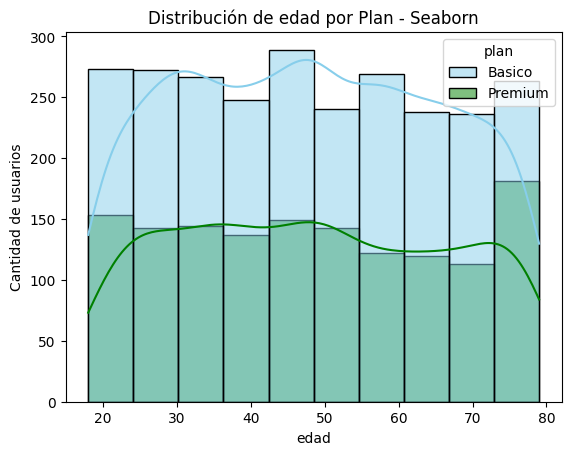

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age', bins=10, hue='plan', palette=['skyblue', 'green'], edgecolor='black', kde=True)
plt.xlabel('edad')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de edad por Plan - Seaborn')
plt.show()

**Insights — Age distribution:**
- Distribution is approximately symmetric and uniform, covering ages 18 to 79 with a mean of ~48 years
- No age preference is observed for plan selection — Basic (~65%) and Premium (~35%) users are proportionally distributed across all age ranges
- The KDE curve confirms the absence of pronounced skew, suggesting ConnectaTel serves a broad demographic without concentration in any specific age group


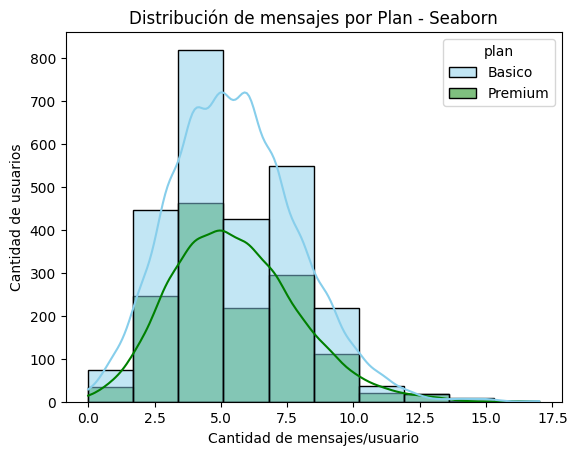

In [33]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='cant_mensajes', bins=10, hue='plan', palette=['skyblue', 'green'], edgecolor='black', kde=True)
plt.xlabel('Cantidad de mensajes/usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de mensajes por Plan - Seaborn')
plt.show()

**Insights — Message volume distribution:**
- Distribution shows a mild right skew. Most users send between 4 and 7 messages, with a median of 5 and a maximum of 17
- Plan type does not significantly affect individual message volume — both Basic and Premium users share the same distributional shape
- The right tail (users sending 10+ messages) represents a small but distinct high-engagement segment


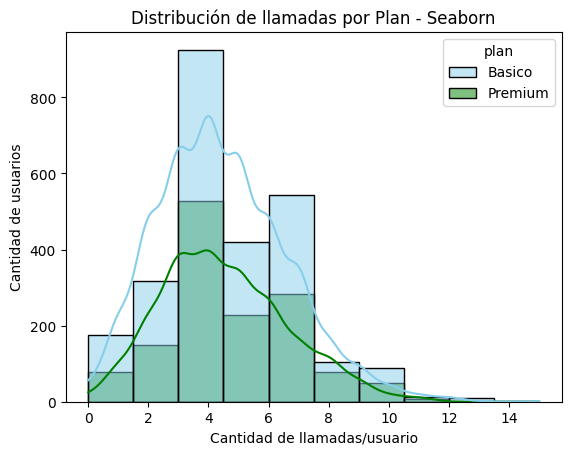

In [34]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x='cant_llamadas', bins=10, hue='plan', palette=['skyblue', 'green'], edgecolor='black', kde=True)
plt.xlabel('Cantidad de llamadas/usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de llamadas por Plan - Seaborn')
plt.show()

**Insights — Call volume distribution:**
- Distribution shows a mild right skew. Most users make between 3 and 6 calls, with a median of 4 and a maximum of 15
- Call behavior is consistent across plan types — plan selection does not predict call frequency
- The small group of users reaching 12–15 calls represents an intensive usage pattern worth monitoring


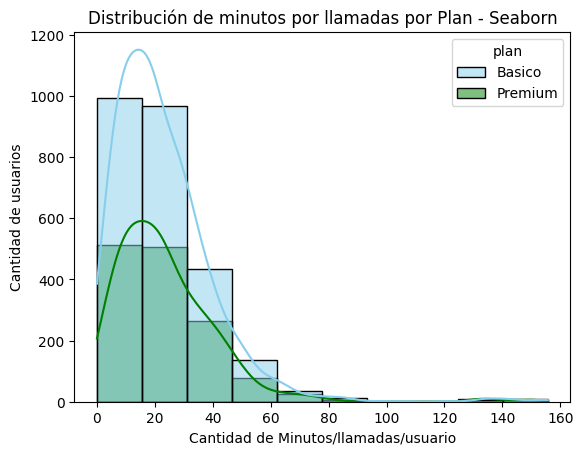

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x='cant_minutos_llamada', bins=10, hue='plan', palette=['skyblue', 'green'], edgecolor='black', kde=True)
plt.xlabel('Cantidad de Minutos/llamadas/usuario')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribución de minutos por llamadas por Plan - Seaborn')
plt.show()

**Insights — Call duration distribution:**
- This is the most right-skewed variable in the dataset. While 50% of users accumulate fewer than 19.78 minutes, the mean is 23.31 minutes, pulled upward by a long right tail reaching 155 minutes
- Both Basic and Premium plans exhibit this skew, but the Basic plan shows a notably higher density of extreme users in the right tail (above 100 minutes)
- These extreme-duration users likely represent high-value customers currently on a plan that may not match their actual consumption needs


### 5.2 Outlier Detection — Boxplots and IQR Method

We generate boxplots for all four numeric variables, then apply the IQR method to quantify outliers in usage columns and decide on treatment.


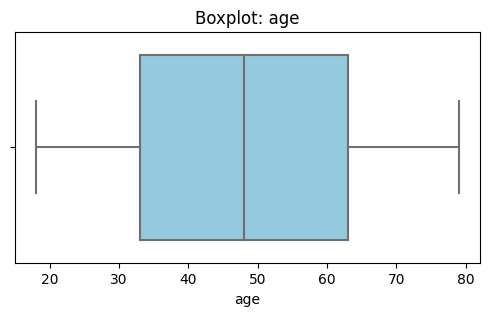

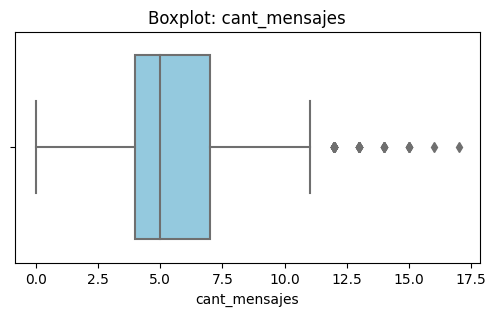

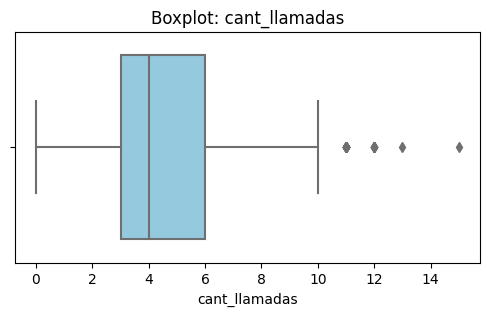

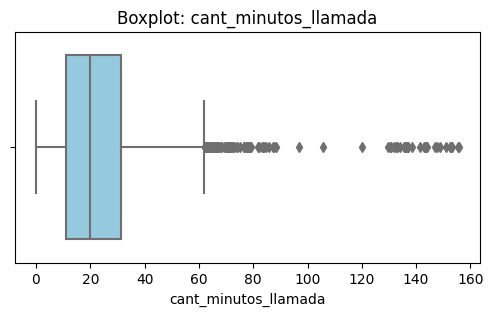

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

**Insights — Boxplot outlier summary:**
- **`age`:** no outliers — values are fully contained within the expected 18–79 range with no extreme points
- **`cant_mensajes`:** outliers present — 46 users exceed the IQR upper bound of 11.5 messages
- **`cant_llamadas`:** outliers present — 30 users exceed the IQR upper bound of 10.5 calls
- **`cant_minutos_llamada`:** most notable outliers — 109 users exceed the IQR upper bound of 61.87 minutes, extending to a maximum of 155.69 minutes


In [37]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    # Calcular Q1 (percentil 25) y Q3 (percentil 75)
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    
    # Calcular el IQR
    iqr = q3 - q1
    
    # Calcular el límite superior formal
    limite_superior = q3 + 1.5 * iqr
    
    # Contar cuántos outliers superan este límite
    total_outliers = (user_profile[col] > limite_superior).sum()
    
    print(f"Columna: {col}")
    print(f"  -> Límite superior: {limite_superior:.2f}")
    print(f"  -> Total de outliers: {total_outliers}\n")



Columna: cant_mensajes
  -> Límite superior: 11.50
  -> Total de outliers: 46

Columna: cant_llamadas
  -> Límite superior: 10.50
  -> Total de outliers: 30

Columna: cant_minutos_llamada
  -> Límite superior: 61.87
  -> Total de outliers: 109



In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


**Outlier treatment decision:**
- **`cant_mensajes`:** outliers **retained**. A maximum of 17 messages per user is a plausible real-world behavior; removing these records would underrepresent high-engagement users
- **`cant_llamadas`:** outliers **retained**. Up to 15 calls is not a system error — it reflects intensive usage patterns that are analytically relevant for segmentation
- **`cant_minutos_llamada`:** outliers **retained**. The 109 users with over 61.87 minutes of call time (up to 155 minutes) are not data capture errors; they represent a distinct high-consumption segment with clear commercial implications for upselling and plan redesign


---

## Step 6: Customer Segmentation

### 6.1 Usage-Based Segmentation

We classify each user into one of three usage tiers based on call and message volume:
- **Low usage** — calls < 5 and messages < 5  
- **Medium usage** — calls < 10 and messages < 10  
- **High usage** — all other cases


In [39]:
# Crear columna grupo_uso
import numpy as np

condiciones = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),  # Condición 1
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10) # Condición 2
]

valores = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(condiciones, valores, default='Alto uso')

In [40]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


In [41]:
# Ver cuántos usuarios quedaron en cada segmento
print(user_profile['grupo_uso'].value_counts())

Uso medio    2943
Bajo uso      779
Alto uso      278
Name: grupo_uso, dtype: int64


### 6.2 Age-Based Segmentation

We classify each user into an age group to support demographic analysis:
- **Young** — age < 30  
- **Adult** — age 30–59  
- **Senior** — age 60+


In [42]:
# Crear columna grupo_edad
import numpy as np

condiciones = [
    (user_profile['age'] < 30),  # Condición 1
    (user_profile['age'] < 60) # Condición 2
]

valores = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(condiciones, valores, default='Adulto Mayor')

In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


In [44]:
# Ver cuántos usuarios quedaron en cada segmento
print(user_profile['grupo_edad'].value_counts())

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64


### 6.3 Segment Distribution — Countplots

We visualize how customers are distributed across usage tiers and age groups.


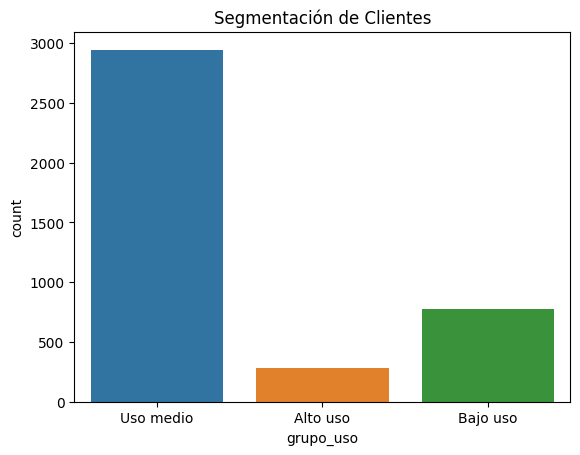

In [45]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x="grupo_uso")
plt.title('Segmentación de Clientes')
plt.xlabel("grupo_uso")
plt.show()

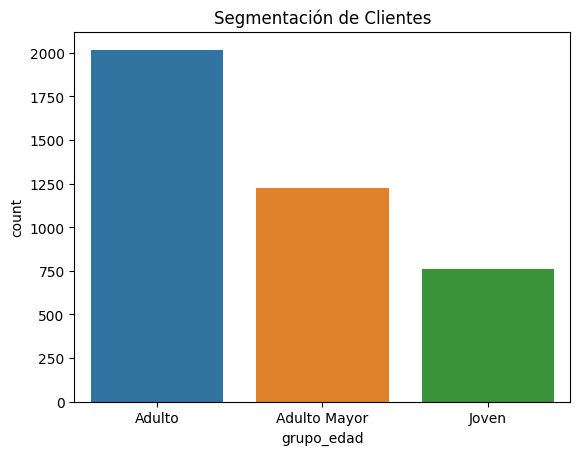

In [46]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x="grupo_edad")
plt.title('Segmentación de Clientes')
plt.xlabel("grupo_edad")
plt.show()


---

## Step 7: Executive Analysis

### Data Quality Issues Found

During the data quality phase, several issues were identified and addressed:

- **`age`**: sentinel value -999 found and replaced with the column median to preserve population distribution  
- **`city`**: 469 null records and 96 entries with `"?"` (14.1% of users without valid location) — unified as `pd.NA`  
- **`reg_date`**: 40 records with year 2026 (1% of dataset) flagged as out-of-range and replaced with `NaT`  
- **`duration` / `length`**: structural nulls confirmed as MAR conditioned on `type` — preserved without imputation  

---

### Customer Segmentation Findings

**By age:**  
- 50.5% Adults (30–59 years), 30.6% Seniors (60+), 19.0% Young (<30)  
- ConnectaTel serves a predominantly mature customer base  
- Age distribution is nearly identical across Basic and Premium plans — age does not drive plan selection  

**By usage level:**  
- 73.6% Medium usage, 19.5% Low usage, 6.95% High usage  
- Most customers maintain moderate, stable consumption patterns  
- The High Usage segment, though small, concentrates significantly above-average consumption levels  

---

### Extreme Usage Patterns

- 109 users exceed the IQR upper limit of 61.87 minutes in call duration (max: 155.69 min)  
- These users likely represent corporate profiles, intensive users, or customers near plan overage thresholds  
- They are prime candidates for upselling or specialized plan offers  

---

### Business Recommendations

1. **Upselling campaign for High Usage segment:** design targeted migration offers to Premium plans for customers with calls ≥ 10 or messages ≥ 10  
2. **Retention monitoring for extreme users:** implement dedicated tracking for the 109 users exceeding 61.87 minutes — identify churn risk and monetization opportunities  
3. **Intermediate plan design:** evaluate a mid-tier plan for Medium Usage customers who consistently approach consumption limits  
4. **Demographic-aligned communication:** adapt campaigns and benefits to the dominant profile (adults and seniors) rather than generic messaging  
5. **Data quality controls:** strengthen validation on date fields and categorical variables to support future churn and behavioral analysis


---

## Key Business Findings

- Data quality issues were identified and corrected across all three datasets before analysis
- Customer age was not a strong predictor of plan selection — Basic and Premium users share nearly identical age distributions
- Usage intensity was a stronger segmentation variable than demographics — 73.6% of customers fall in the medium usage tier
- 109 high-consumption users (call duration > 61.87 min) represent a measurable upselling opportunity for Premium plan migration
- Structural missing values in `duration` and `length` were validated as business-driven (MAR conditioned on `type`) rather than data quality issues — no imputation was required


## Limitations

- Analysis is limited to the variables available in the three source datasets — no external enrichment was applied
- Revenue data was not available; commercial impact of segmentation recommendations could not be quantified
- Customer tenure analysis was partially affected by 40 missing registration dates (year 2026 anomalies replaced with `NaT`)
- Additional behavioral variables (data consumption, roaming, support interactions) could improve segmentation accuracy and churn prediction


---

## Step 8: Reproducibility

### How to Run This Notebook

1. Open this notebook in **Google Colab** using the badge in the repository README  
2. Mount the datasets in the `/datasets/` path or update the `pd.read_csv()` paths to point to the local files  
3. Run all cells in order (`Runtime → Run all`)  

### Repository Structure

```
telecom-customer-analysis/
├── notebooks/
│   └── connectatel_analysis.ipynb
├── data/
│   ├── plans.csv
│   ├── users_latam.csv
│   └── usage.csv
└── README.md
```


**Public repository:** [github.com/williambernal-data/telecom-customer-analysis](https://github.com/williambernal-data/telecom-customer-analysis)
